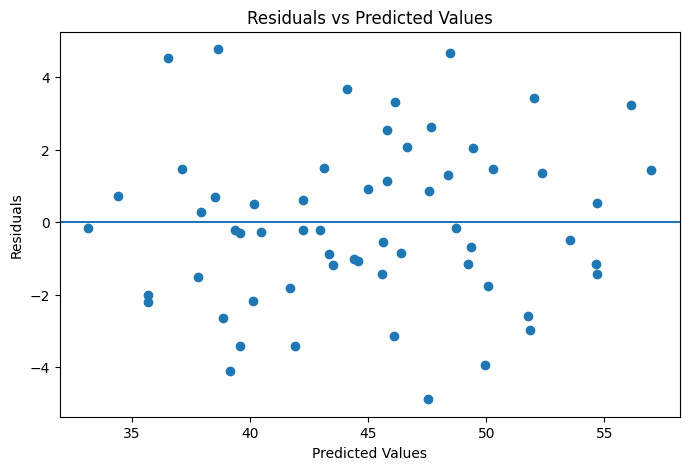

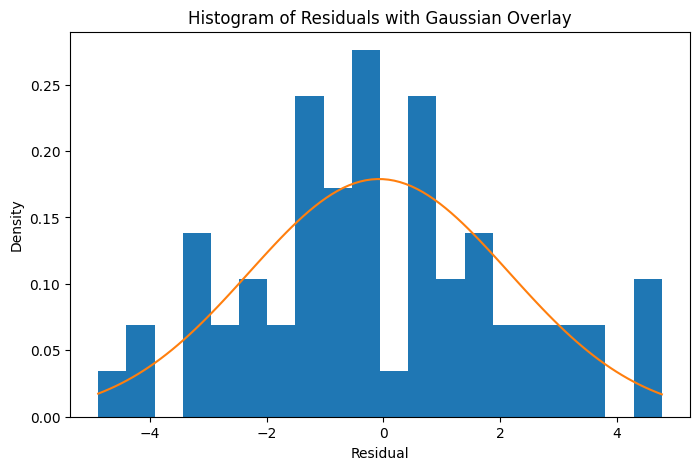

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import norm


np.random.seed(42)
n = 300

hours_op = np.random.uniform(0, 10, n)
ambient = np.random.uniform(20, 40, n)
load_pct = np.random.uniform(0.2, 1.0, n)
voltage = np.random.uniform(210, 240, n)

X = np.column_stack((hours_op, ambient, load_pct, voltage))

noise = np.random.normal(0, 2, n)

y = (
    0.8 * hours_op +
    0.5 * ambient +
    25 * load_pct +
    0.05 * voltage +
    noise
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LinearRegression()
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)


residuals = y_test - y_pred


plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)


plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()


plt.figure(figsize=(8, 5))


count, bins, ignored = plt.hist(
    residuals,
    bins=20,
    density=True
)

mu = np.mean(residuals)
sigma = np.std(residuals)

x = np.linspace(bins.min(), bins.max(), 100)
gaussian = norm.pdf(x, mu, sigma)

plt.plot(x, gaussian)

plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Histogram of Residuals with Gaussian Overlay")

plt.show()